In [16]:

import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
from IPython.display import display, Markdown, Latex
import pandas as pd
from uncertainties import ufloat
from uncertainties import unumpy as unp
from scipy.optimize import curve_fit
from scipy import constants as const 

# PW7

## Experiment 1:


$$
\frac{I_1}{I_2} = \frac{a_1}{a_2}
$$


$$
\frac{P_1}{P_2} = \frac{T_1^{4}}{T_2^{4}}
$$
$$
\ln\!\left(\frac{I_1}{I_2}\right)
= \frac{1}{T_1}
\left[
\left(\frac{P_1}{P_2}\right)^{1/4} - 1
\right]
\left(\frac{c h}{k \lambda}\right)
$$


Chi2^1: 1.6775843378183461
Reduced Chi1^2: 0.20969804222729327
Reduced Chi1^2 = 0,21
Chi2^2: 0.24750915750522692
Reduced Chi2^2: 0.030938644688153365
Reduces Chi2^2 = 0,03


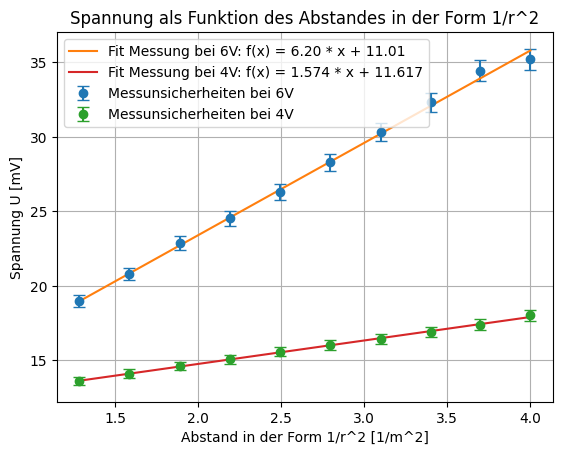

Die Steigung des Fits bei 6V beträgt (6.20+/-0.19)mV*m^2. Die Steigung des Fits bei 4V beträgt (1.57+/-0.11)mV*m^2.
Das Verhältnis der beiden Lichtstärken zueinander beträgt 3.936+/-0.312.
Die elektrische Leistung unter der ersten Betriebsbedingung liegt bei (27.19+/-0.38)W. Die elektrische Leistung unter der zweiten Betriebsbedingung liegt bei (14.59+/-0.21)W.
Bei 6V hatte das Licht eine Temperatur (3049.72+/-205.71)K, bei 4V hatte das Licht eine Temperatur von (2610.05+/-169.71)K.


In [26]:
# 1. Experiment

# E ist proportional zu U, daher hier gleich benutzt

# Spannung 1 = 6V
e_messwerte_1 = np.array([35.2, 34.45, 32.33, 30.3, 28.29, 26.31, 24.54, 22.88, 20.79, 18.98]) # Spannung in mV
e_unsicherheiten_1 = (e_messwerte_1*0.02)  # Unsicherheit Multimeter 0,8% + 3D
unsicherheiten_für_fit_1 = unp.nominal_values(e_unsicherheiten_1) # nimmt die Zahlenwerte von den einzelnen berechneten Unsicherheiten der Messreihe
e_werte_1 = unp.uarray(e_messwerte_1, e_unsicherheiten_1) # fügt Werte und Unsicherheiten zu einem Array zusammen

r_messwerte_1 = np.array([0.5, 0.52, 0.542, 0.568, 0.598, 0.633, 0.675, 0.727, 0.794, 0.882]) # Messreihe Abstände, welche dann im 1/r^2 tatsächlich äquidistant sind
r_unsicherheiten_1 = 0.0005 # Unsicherheit Abstandsmessung in m (hier 0,5mm)
r_werte_1 = unp.uarray(r_messwerte_1, r_unsicherheiten_1) # Fügt Werte und Unsicherheiten zu einem Array zusammen
r_als_quotient_1 = 1/(r_werte_1)**2 # 1/r^2 als Array mit Unsicherheit und den tatsächlichen Werten
r_quot_nom_1 = unp.nominal_values(r_als_quotient_1) # nimmt die reinen Zahlenwerte aus dem Array r_als_quotient_1 

# Spannung 2 = 4V (es passiert das gleiche wie oben)
e_messwerte_2 = np.array([18.04, 17.4, 16.9, 16.43, 16.02, 15.58, 15.08, 14.62, 14.12, 13.63]) # Spannung in mV
e_unsicherheiten_2 = (e_messwerte_2*0.02) 
unsicherheiten_für_fit_2 = unp.nominal_values(e_unsicherheiten_2)
e_werte_2 = unp.uarray(e_messwerte_2, e_unsicherheiten_2)

# es werden die exakt gleichen Abstände für die zweite Spannungsmessung genommen
r_messwerte_2 = r_messwerte_1
r_unsicherheiten_2 = r_unsicherheiten_1
r_werte_2 = r_werte_1
r_als_quotient_2 = r_als_quotient_1
r_quot_nom_2 = r_quot_nom_1

x = unp.nominal_values(r_als_quotient_1) # benennen r_quot_nom_1 um in x (und damit auch r_quot_nom_2)

# Aufstellen der linearen Grundgleichung
def linear(x, m, b):
    return m*x + b


popt, pcov = curve_fit(linear, x, e_messwerte_1, sigma=unsicherheiten_für_fit_1, absolute_sigma=True)
# curve_fit probiert die e_messwerte_1 durch einen linearen Fit zu beschreiben, wobei x=1/r^2
# sigma gewichtet die Messpunkte mit ihren Fehlern
# absolute_sigma beachtet, dass die Fehler physikalisch korrekt behandelt werden
m, b = popt # Steigung, Achsenabschnitt
dm, db = np.sqrt(np.diag(pcov)) # Fehler für Steigung und Achsenabschnitt (Standardabweichung)

residuals1 = e_messwerte_1 - linear(x, m, b)
chi1 = np.sum((residuals1 / unsicherheiten_für_fit_1)**2)

ndof1 = len(v) - len(popt)

chi1_red = chi1 / ndof1

print("Chi2^1:", chi1)
print("Reduced Chi1^2:", chi1_red)
print("Reduced Chi1^2 = 0,21")

x_fit = np.linspace(x.min(), x.max(), 200) # erstellt 200 gleichmäßig verteilte x-Werte in dem Messintervall
y_fit = linear(x_fit, m, b) # berechnet die zugehörigen y-Werte

v = unp.nominal_values(r_als_quotient_2) # für die 2. Spannung wird x in v umbenannt

# ab hier passiert wieder exakt das gleiche wie oben (nur mit c=Steigung und d=Achsenabschnitt)
def linear2(v, c, d):
    return c*v + d

popt, pcov = curve_fit(linear2, v, e_messwerte_2, sigma=unsicherheiten_für_fit_2, absolute_sigma=True)
c, d = popt
dc, dd = np.sqrt(np.diag(pcov))

# --- Chi^2 ---
residuals = e_messwerte_2 - linear2(v, c, d)
chi2 = np.sum((residuals / unsicherheiten_für_fit_2)**2)

# --- Degrees of freedom ---
ndof = len(v) - len(popt)

# --- Reduced chi^2 ---
chi2_red = chi2 / ndof

print("Chi2^2:", chi2)
print("Reduced Chi2^2:", chi2_red)
print("Reduces Chi2^2 = 0,03")

v_fit = np.linspace(v.min(), v.max(), 200)
w_fit = linear2(v_fit, c, d)

# gegeneinander auftragen e bzw u anpassen
plt.errorbar(r_quot_nom_1, e_messwerte_1, yerr=e_unsicherheiten_1, fmt="o", capsize=4, label="Messunsicherheiten bei 6V") 
# zeichnet Messpunkte mit Fehlerbalken (Messpunkte als o, Größe der Balken am Ende der Fehlerbalken (4) und Legendenbeschriftung)
plt.plot(x_fit, y_fit, label=f"Fit Messung bei 6V: f(x) = {m:.2f} * x + {b:.2f}")
# plottet die Fitgerade mit Angabe der Fubktionsgleichung, wobei m und b auf 3 Nachkommastellen berechnet werden

# hier das gleiche für die Spannung=4V
plt.errorbar(r_quot_nom_2, e_messwerte_2, yerr=e_unsicherheiten_2, fmt="o", capsize=4, label="Messunsicherheiten bei 4V")
plt.plot(v_fit, w_fit, label=f"Fit Messung bei 4V: f(x) = {c:.3f} * x + {d:.3f}")

plt.xlabel("Abstand in der Form 1/r^2 [1/m^2]") # x-Achse Beschriftung
plt.ylabel("Spannung U [mV]") # y-Achse Beschriftung
plt.title("Spannung als Funktion des Abstandes in der Form 1/r^2") # Überschrift Plot
plt.legend() # zeigt Legende an
plt.grid(True) # zeigt Gitter an zur Orientierung
plt.show() # zeigt alles an

print(f"Die Steigung des Fits bei 6V beträgt ({m:.2f}+/-{dm:.2f})mV*m^2. Die Steigung des Fits bei 4V beträgt ({c:.2f}+/-{dc:.2f})mV*m^2.")
# f-String; alles in {} wird durch Klammern ersetzt

# Berechnen jetzt das Verhältnis der Lichtstärken I1/I2 aus dem Verhältnis der Steigungen 
J = m/c
dJ = J * np.sqrt((dm/m)**2 + (dc/c)**2) # Unsicherheit aus Gauß
verhältnis = ufloat(J, dJ)

print(f"Das Verhältnis der beiden Lichtstärken zueinander beträgt {verhältnis:.3f}.")

# zur Bestimmung der elektrischen Leistung und der Strahlungstemperatur
v1 = ufloat(6, (6*0.01)) # Float mit Unsicherheit (Unsicherheit aus der Geräteangabe 0,3% +3D); Spannung 1 [V]
a1 = ufloat(4.532, (4.532*0.01)) #Float mit Unsicherheit (Unsicherheit aus der Geräteangabe 0,5% + 3D) Strom 1 [A]
p1 = v1 * a1 # Spannung * Strom
# nochmal für p2
v2 = ufloat(4, (4*0.01))
a2= ufloat(3.647, (3.647*0.01))
p2 = a2 * v2
# p1 und p2 haben beide eine Unsicherheit, weil v1,v2 und a1,a2 ufloats sind!

f = const.Boltzmann * 580*10**(-9) # Boltzmann * Wellenlänge von 580nm
g = const.c * const.h # Lichtgeschwindigkeit * Plancksches Wirkungsquantum 

# Formeln aus dem Vorbereitungstext umstellen
t1 = (((p1/p2)**(1/4))-1)*(g/f)/(unp.log(verhältnis)) 
t2 = ((1-((p2/p1)**(1/4)))*(g/f))/unp.log(verhältnis) 

print(f"Die elektrische Leistung unter der ersten Betriebsbedingung liegt bei ({p1:.2f})W. Die elektrische Leistung unter der zweiten Betriebsbedingung liegt bei ({p2:.2f})W.")
print(f"Bei 6V hatte das Licht eine Temperatur ({t1:.2f})K, bei 4V hatte das Licht eine Temperatur von ({t2:.2f})K.")



## Experiment 2

$$ 
\frac{\Delta Q}{\Delta t} = - \lambda A \frac{\Delta T}{\Delta x} 
$$


In [24]:
# 2. Experiment 

A = ufloat(10 * 4 * 10**(-6), 5*10**(-7)) # Flächenmessung in mm^2 (daher 10^(-6)); Unsicherheit 0,5 mm^2
anstieg = ufloat(-0.1 * 10**3, 0.001) # Steigung, die aus dem Rechner ermittelt werden muss
P = 0.6 # Leistung in Watt (deltaQ/deltat = U^2/R)

lambda_ = -(P/(anstieg*A)) # Wärmeleitfähigkeit 

print(f"Die Wärmeleitfähigkeit des Materials ist ({lambda_:.2f}) J/msK, dementsprechend handelt es sich bei der untersuchten Probe um Daulaluminium mit einer Wärmeleitfähigkeit von 170 J/msK (siehe Anleitungstext).")

# Duraluminium 170 J/msK
# Aluminium 235 J/msK



Die Wärmeleitfähigkeit des Materials ist (150.00+/-1.88) J/msK, dementsprechend handelt es sich bei der untersuchten Probe um Daulaluminium mit einer Wärmeleitfähigkeit von 170 J/msK (siehe Anleitungstext).


![Bildschirmfoto vom 2025-11-25 16-12-09.jpeg](<attachment:Bildschirmfoto vom 2025-11-25 16-12-09.jpeg>)
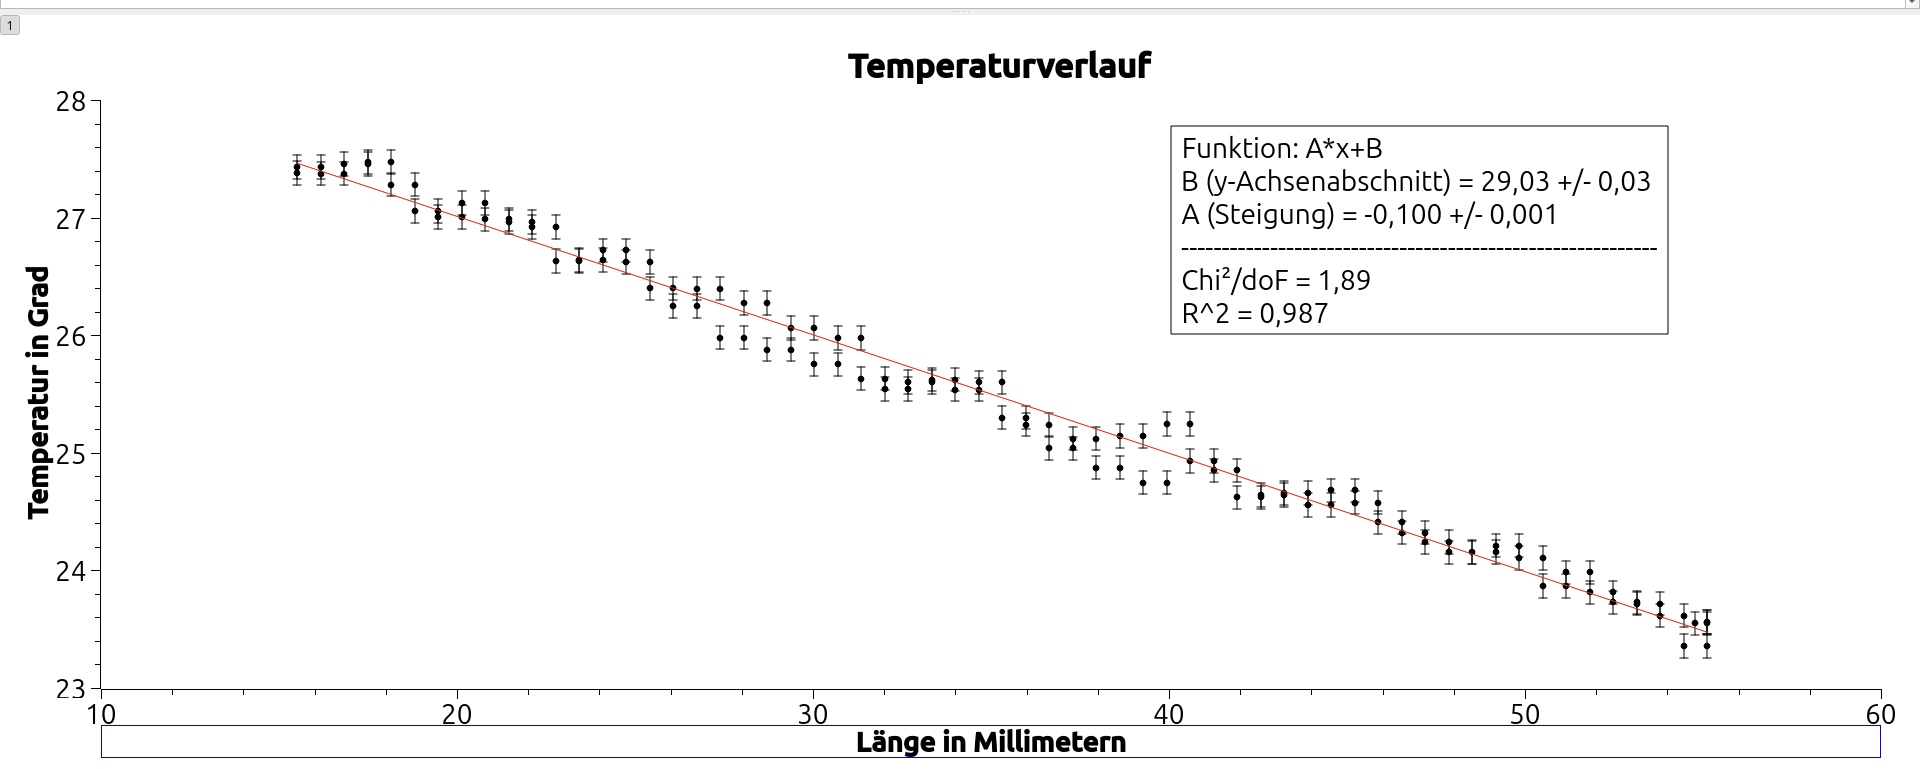